In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 读取信息表和销售数据表
info = pd.read_excel('商品销售数据.xlsx', sheet_name='信息表')
sales = pd.read_excel('商品销售数据.xlsx', sheet_name='销售数据表')

# 按商品编号合并（保留销售数据表所有行）
data = pd.merge(info, sales, on='商品编号', how='right')
data.head()  # 查看前几行

,商品大类,商品小类,商品名称,商品编号,商品销售价,订单日期,订单编号,订单数量
0,运动配饰,发带,纯色弹力发带,fd003,12.0,2022-01-01,HS2022000001,26
1,运动配饰,发带,糖果色弹力发带,fd004,16.0,2022-01-01,HS2022000002,28
2,运动配饰,手环,篮球运动手环,sh001,8.0,2022-01-01,HS2022000003,20
3,运动配饰,手环,小清新硅胶手环,sh003,6.0,2022-01-01,HS2022000004,35
4,运动上装,背心,跑步运动背心,bx002,39.0,2022-01-01,HS2022000005,60


In [3]:
# 销售金额 = 销售价 × 订单数量
data['销售金额'] = data['商品销售价'] * data['订单数量']

# 将订单日期转为 datetime 类型，并提取月份
data['订单日期'] = pd.to_datetime(data['订单日期'])
data['月份'] = data['订单日期'].dt.month

data.head()

,商品大类,商品小类,商品名称,商品编号,商品销售价,订单日期,订单编号,订单数量,销售金额,月份
0,运动配饰,发带,纯色弹力发带,fd003,12.0,2022-01-01,HS2022000001,26,312.0,1
1,运动配饰,发带,糖果色弹力发带,fd004,16.0,2022-01-01,HS2022000002,28,448.0,1
2,运动配饰,手环,篮球运动手环,sh001,8.0,2022-01-01,HS2022000003,20,160.0,1
3,运动配饰,手环,小清新硅胶手环,sh003,6.0,2022-01-01,HS2022000004,35,210.0,1
4,运动上装,背心,跑步运动背心,bx002,39.0,2022-01-01,HS2022000005,60,2340.0,1


In [4]:
# 解决 Matplotlib 中文乱码问题
import matplotlib.pyplot as plt

# 设置全局字体为支持中文的字体（Windows 系统通用）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号 '-' 显示为方块的问题

    月份      销售金额
0    1  344878.0
1    2  375111.0
2    3  431575.0
3    4  408359.0
4    5  463358.0
5    6  424416.0
6    7  490090.0
7    8  468356.0
8    9  433489.0
9   10  485727.0
10  11  484643.0
11  12  470306.0


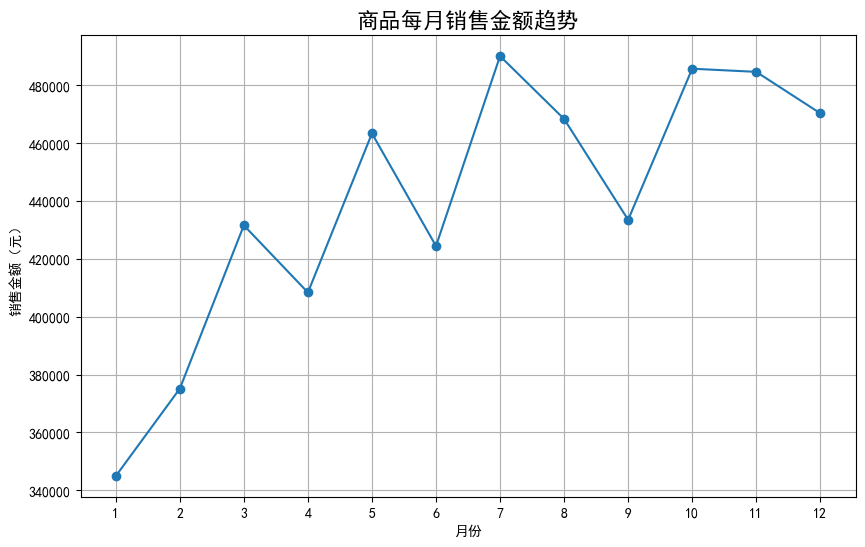

In [5]:
# 按月份分组求和
monthly_sales = data.groupby('月份')['销售金额'].sum().reset_index()
print(monthly_sales)

# 绘制折线图
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales['月份'], monthly_sales['销售金额'], marker='o', linestyle='-')
plt.title('商品每月销售金额趋势', fontsize=16)
plt.xlabel('月份')
plt.ylabel('销售金额（元）')
plt.xticks(range(1, 13))  # 显示1~12月
plt.grid(True)
plt.show()

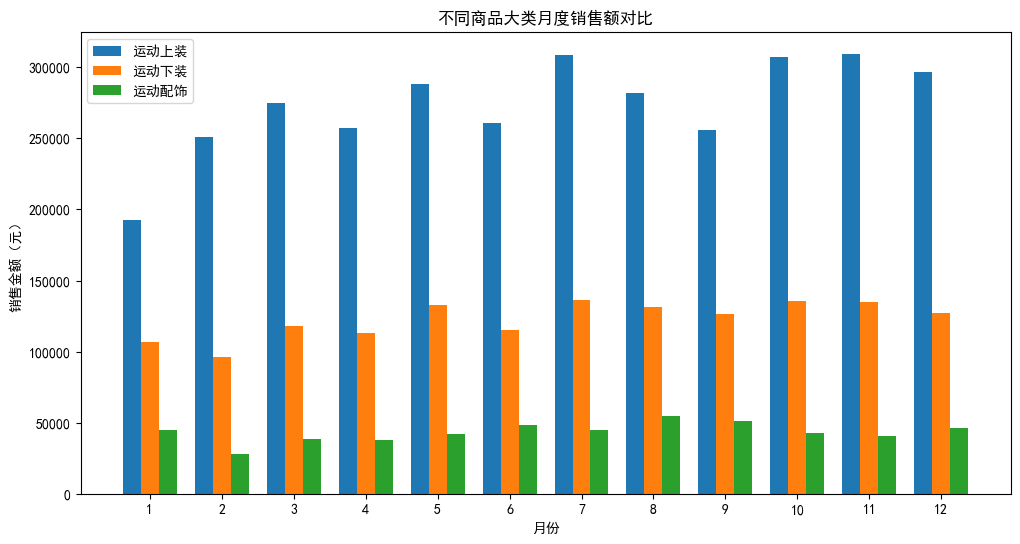

In [6]:
# 按月份和商品大类分组汇总
category_monthly = data.groupby(['月份', '商品大类'])['销售金额'].sum().reset_index()

# 提取三大类数据
tops = category_monthly[category_monthly['商品大类'] == '运动上装']
bottoms = category_monthly[category_monthly['商品大类'] == '运动下装']
accessories = category_monthly[category_monthly['商品大类'] == '运动配饰']

# 绘制柱状图（并排）
x = range(1, 13)
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar([i - width for i in x], tops['销售金额'], width, label='运动上装')
plt.bar(x, bottoms['销售金额'], width, label='运动下装')
plt.bar([i + width for i in x], accessories['销售金额'], width, label='运动配饰')

plt.xlabel('月份')
plt.ylabel('销售金额（元）')
plt.title('不同商品大类月度销售额对比')
plt.xticks(x)
plt.legend()
plt.show()

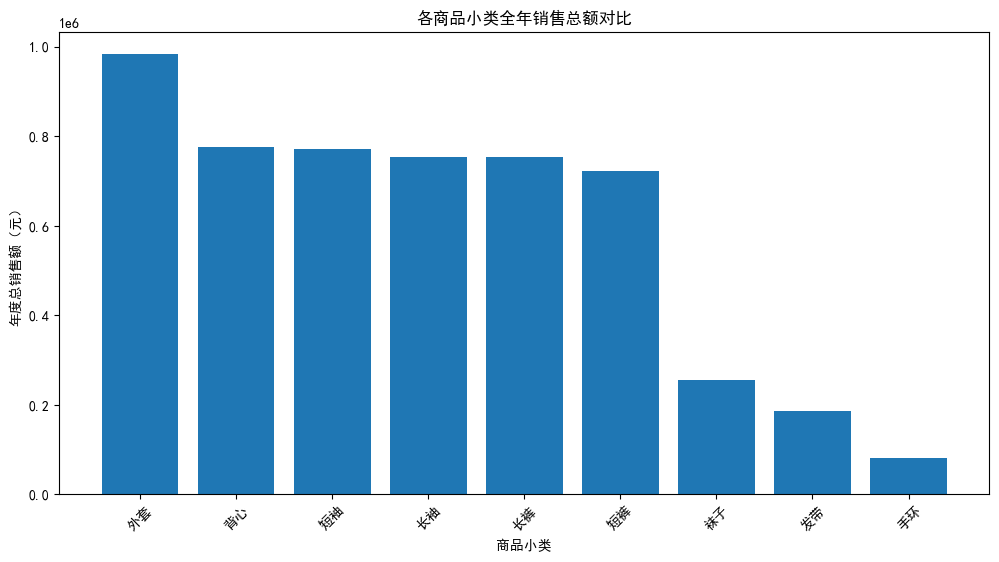

In [7]:
# 按商品小类汇总全年总销售额
subcategory_total = data.groupby('商品小类')['销售金额'].sum().reset_index()
subcategory_total = subcategory_total.sort_values('销售金额', ascending=False)  # 降序排列

plt.figure(figsize=(12, 6))
plt.bar(subcategory_total['商品小类'], subcategory_total['销售金额'])
plt.xlabel('商品小类')
plt.ylabel('年度总销售额（元）')
plt.title('各商品小类全年销售总额对比')
plt.xticks(rotation=45)  # 旋转标签，防止重叠
plt.show()